In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/9
    print("準備完了！このまま下のセルを実行できます。")

# 第9章 正則化 (Regularization)
## 9.3 学習曲線 (Learning Curves)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第9章「正則化」第9.3節「学習曲線 (Learning Curves)」の完全な理論解説、数学的導出、再利用可能なPythonモジュール実装、および全図版再現 (Figure 9.7, Figure 9.8, Figure 9.9, Figure 9.10, Figure 9.11) を提供します。

---

### 目次
1. **9.3.1 早期終了 (Early Stopping)**
   - 反復的学習における訓練誤差と検証誤差の推移
   - 検証誤差の最小値による最適早期終了ポイントの決定
   - **Figure 9.7 再現**: 正弦波データセットにおける典型的な学習曲線
   - 2次誤差曲面における早期終了と重み減衰の数学的等価性 (Bishop, 1995a)
   - 連続勾配流 $\mathbf{w}(t) = (\mathbf{I} - e^{-\mathbf{H} t}) \mathbf{w}^\star$ と主軸座標系での解析
   - 正則化係数と反復回数の定量関係 $\tau \eta \sim \frac{1}{\lambda}$ (演習 9.6)
   - **Figure 9.8 再現**: 2次誤差曲面における勾配軌道と早期終了解 $\widehat{\mathbf{w}}$ の幾何構造
2. **9.3.2 二重降下現象 (Double Descent)**
   - 古典的統計学の信念（バイアス・バリアンス・トレードオフ）と深層学習の経験知（過剰パラメータ化の優位性）の矛盾
   - Belkin et al. (2019) と Nakkiran et al. (2019) による二重降下現象の発見と統一的解釈
   - 3つの複雑さ領域：古典領域・臨界領域（補間閾値）・現代領域
   - **Figure 9.9 再現**: ResNet18 の幅パラメータに対するモデル別二重降下現象
   - **Figure 9.10 再現**: エポック数に対するエポック別二重降下現象（小・中・大モデルの比較）
   - **Figure 9.11 再現**: サンプル数増大が逆効果をもたらすサンプル別非単調性（Transformer埋め込み次元とサンプルサイズのパラドックス）
3. **まとめと第9.4節（パラメータ共有・ソフト重み共有）への展望**


In [1]:
# 実行環境のセットアップと共通モジュールのインポート
import sys
from pathlib import Path

# リポジトリルートをPythonパスに追加
repo_root = Path.cwd()
if not (repo_root / "common").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt

# common.learning_curves から各クラス・関数をインポート
from common.learning_curves import (
    EarlyStoppingAnalysis,
    GradientFlowShrinkage,
    DoubleDescentModel,
    generate_figure_9_7,
    generate_figure_9_8,
    generate_figure_9_9,
    generate_figure_9_10,
    generate_figure_9_11,
)

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Working Directory: {Path.cwd()}")


Python: 3.11.12
NumPy: 2.4.4
Working Directory: /home/student/Documents/GitHub/my_DeepLearning/9


---
## 1. 早期終了 (Early Stopping - Section 9.3.1)

### 1.1 学習曲線と最適停止点

深層ニューラルネットワークの学習は、訓練データ集合に対して定義された誤差関数の反復的な勾配降下法（または確率的勾配降下法 SGD）によって行われます。
- **訓練誤差 (Training Set Error)**: 反復ステップ数の増加に伴い、通常は広範に単調減少します。
- **検証誤差 (Validation Set Error)**: 独立したホールドアウトデータに対して評価した誤差は、初期は減少するものの、モデルが訓練データのノイズに過剰適合し始めると再び増加に転じます。

したがって、最良の汎化性能を達成するためには、**検証誤差が最小となる反復ステップで学習を停止（早期終了, Early Stopping）** する必要があります。


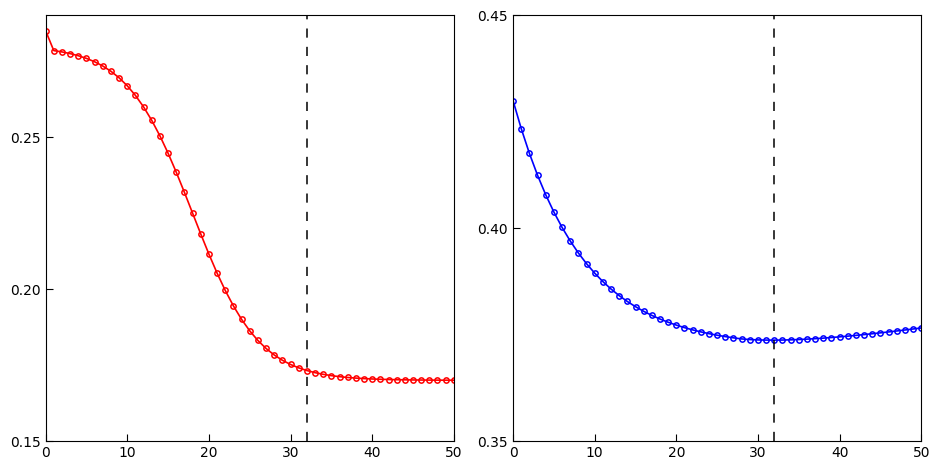

総反復ステップ数: 51
最適早期終了ステップ tau*: 32
最適検証誤差: 0.3737
学習完了時 (Step 50) の検証誤差: 0.3766
早期終了による誤差削減量: 0.0029


In [2]:
# Figure 9.7 の再現: 訓練誤差（左）と検証誤差（右）の推移
fig9_7 = generate_figure_9_7()
plt.show()

# 数値的検証: EarlyStoppingAnalysis による最適ステップの同定
analyzer = EarlyStoppingAnalysis(n_steps=51)
print(f"総反復ステップ数: {analyzer.n_steps}")
print(f"最適早期終了ステップ tau*: {analyzer.best_step}")
print(f"最適検証誤差: {analyzer.best_val_error:.4f}")
print(f"学習完了時 (Step 50) の検証誤差: {analyzer.final_val_error:.4f}")
print(f"早期終了による誤差削減量: {analyzer.error_reduction_from_early_stopping():.4f}")


### 1.2 早期終了と重み減衰の数学的等価性 (Bishop, 1995a)

早期終了は経験的なテクニックとして広く使われますが、2次誤差曲面においては**重み減衰（$L_2$ 正則化）と数学的に本質的に等価である**ことが証明されています（Bishop 1995a, 演習 9.6）。

未正則化誤差関数の2次近似：
$$
E(\mathbf{w}) = E(\mathbf{w}^\star) + \frac{1}{2} (\mathbf{w} - \mathbf{w}^\star)^T \mathbf{H} (\mathbf{w} - \mathbf{w}^\star)
$$
を考えます。ここで $\mathbf{w}^\star$ は最尤解（非正則化最適点）、$\mathbf{H}$ は正定値ヘッセ行列です。

原点 $\mathbf{w}(0) = \mathbf{0}$ から開始する連続時間の最急降下法（勾配流, Gradient Flow）：
$$
\frac{d\mathbf{w}}{dt} = -\nabla E(\mathbf{w}) = -\mathbf{H} (\mathbf{w} - \mathbf{w}^\star)
$$
の厳密解は、行列指数関数を用いて次のように求まります：
$$
\mathbf{w}(t) = \mathbf{w}^\star - \exp(-\mathbf{H} t) \mathbf{w}^\star = (\mathbf{I} - \exp(-\mathbf{H} t)) \mathbf{w}^\star
$$
ヘッセ行列の固有値 $\eta_i$ と正規直交固有ベクトル $\mathbf{u}_i$ の座標系において各成分 $w_i(t) = \mathbf{u}_i^T \mathbf{w}(t)$ を見ると：
$$
w_i(t) = (1 - e^{-\eta_i t}) w_i^\star
$$
これを第9.2節の重み減衰解と比較します：
$$
\widehat{w}_i = \frac{\eta_i}{\eta_i + \lambda} w_i^\star = \left( 1 + \frac{\lambda}{\eta_i} \right)^{-1} w_i^\star
$$

#### 収縮係数の比較
- $\eta_i t \ll 1$ のとき、テイラー展開より $1 - e^{-\eta_i t} \approx \eta_i t$ です。
- 一方、$\lambda / \eta_i \gg 1$ のとき、$(1 + \lambda / \eta_i)^{-1} \approx \eta_i / \lambda$ です。
両者を比較すると、連続時間 $t$ は**正則化パラメータの逆数 $1/\lambda$** に対応します：
$$
t \approx \frac{1}{\lambda}
$$
学習率 $\eta$ による離散ステップ更新 $\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} - \eta \nabla E(\mathbf{w}^{(\tau)})$ では、$t = \tau \eta$ となるため：
$$
\tau \eta \sim \frac{1}{\lambda}
$$
が成り立ちます。
- **学習の初期 ($\tau$ が小さい $\iff \lambda$ が大きい)**:
  有効パラメータ数は小さく、モデルは単純（原点近傍）。
- **大きな固有値 $\eta_2$ の方向**:
  減衰率 $e^{-\eta_2 t}$ が急激に減少し、パラメータ $w_2$ は極めて速く最適値 $w_2^\star$ に到達します。
- **小さな固有値 $\eta_1$ の方向**:
  減衰率 $e^{-\eta_1 t} \approx 1 - \eta_1 t$ のままであり、パラメータ $w_1$ はほとんどゼロに留まります。

したがって、早期に学習を停止すると、ヘッセ行列の主軸において感度の低い方向のパラメータが抑制され、第9.2節の Figure 9.3 で示した重み減衰と定性的に全く同じ解 $\widehat{\mathbf{w}}$ が得られます。


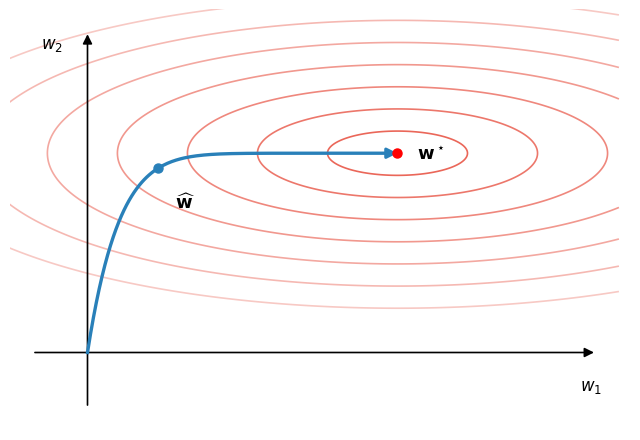

=== 早期終了 (勾配流) vs 重み減衰の比較 ===
t = 0.5 (勾配流): w = [0.508, 1.556]  (w1収縮: 18.1%, w2収縮: 86.5%)
lambda = 2.0 (重み減衰): w = [0.467, 1.200]  (w1収縮: 16.7%, w2収縮: 66.7%)

t = 1.0 (勾配流): w = [0.923, 1.767]  (w1収縮: 33.0%, w2収縮: 98.2%)
lambda = 1.0 (重み減衰): w = [0.800, 1.440]  (w1収縮: 28.6%, w2収縮: 80.0%)

t = 2.5 (勾配流): w = [1.770, 1.800]  (w1収縮: 63.2%, w2収縮: 100.0%)
lambda = 0.4 (重み減衰): w = [1.400, 1.636]  (w1収縮: 50.0%, w2収縮: 90.9%)



In [3]:
# Figure 9.8 の再現: 2次誤差曲面における勾配軌道と早期終了解
fig9_8 = generate_figure_9_8()
plt.show()

# 勾配流の解析解と重み減衰解の数値比較
eta1, eta2 = 0.4, 4.0
H = np.diag([eta1, eta2])
w_star = np.array([2.8, 1.8])
flow = GradientFlowShrinkage(H=H, w_star=w_star)

print("=== 早期終了 (勾配流) vs 重み減衰の比較 ===")
for t_val, lam_val in [(0.5, 2.0), (1.0, 1.0), (2.5, 0.4)]:
    w_flow = flow.gradient_flow_point(t=t_val)
    w_decay = flow.weight_decay_point(lambda_reg=lam_val)
    print(f"t = {t_val:.1f} (勾配流): w = [{w_flow[0]:.3f}, {w_flow[1]:.3f}]  (w1収縮: {w_flow[0]/w_star[0]:.1%}, w2収縮: {w_flow[1]/w_star[1]:.1%})")
    print(f"lambda = {lam_val:.1f} (重み減衰): w = [{w_decay[0]:.3f}, {w_decay[1]:.3f}]  (w1収縮: {w_decay[0]/w_star[0]:.1%}, w2収縮: {w_decay[1]/w_star[1]:.1%})\n")


---
## 2. 二重降下現象 (Double Descent - Section 9.3.2)

### 2.1 古典的信念と現代的知見の対立

- **古典的統計学の信念 (Classical View)**:
  モデルのパラメータ数が増加すると、バイアスは低下するがバリアンスが増大する（バイアス・バリアンス・トレードオフ, 第4.3節）。訓練データの大きさに応じてパラメータ数を適切に制限しなければならず、訓練データを完全に記憶するような巨大モデルは深刻な過適合に陥ると考えられていました。
- **現代の深層学習の知見 (Modern Deep Learning Wisdom)**:
  パラメータ数が訓練サンプル数を大幅に上回る超巨大ニューラルネットワーク（数億〜数千億パラメータ）が、訓練誤差ゼロを達成しながらも、テストデータに対して極めて優れた汎化性能を示します（"Bigger models are better", Zhang et al., 2016）。

この一見矛盾する2つの視点を統合的に解明したのが、Belkin et al. (2019) および Nakkiran et al. (2019) によって提唱された**二重降下現象 (Double Descent)** です。


### 2.2 モデル別二重降下 (Model-wise Double Descent)

二重降下現象では、横軸にモデルの複雑さ（ResNet18 の隠れ層ユニット数を決定する幅パラメータなど）をとったとき、テスト誤差曲線が**2つの異なる下降領域（Double Descent）**を示します：

1. **古典領域 (Classical Underparameterized Regime)**:
   モデルの自由度が訓練データ数より少ない領域。バイアス・バリアンス・トレードオフに従い、モデルが複雑になるにつれて汎化誤差がU字型に下降します。
2. **臨界領域・補間閾値 (Critical Regime / Interpolation Threshold)**:
   モデルの実効的な容量が訓練データを完全にフィット（訓練誤差ゼロ）できる境界。ここではグラム行列が特異（悪条件）となり、パラメータノルムが急拡大し、テスト誤差に巨大なスパイク（山）が生じます。
3. **現代領域 (Modern Overparameterized Regime)**:
   モデル容量が補間閾値を大きく超えた領域。データに完全適合するパラメータ解が無数に存在する中で、勾配降下法（SGD）が持つ**暗黙の正則化バイアス (Implicit Bias)**（最小ノルム解の選択）が働き、モデルが大きくなるほど関数の平滑性が向上し、テスト誤差は単調に減少し続けます。


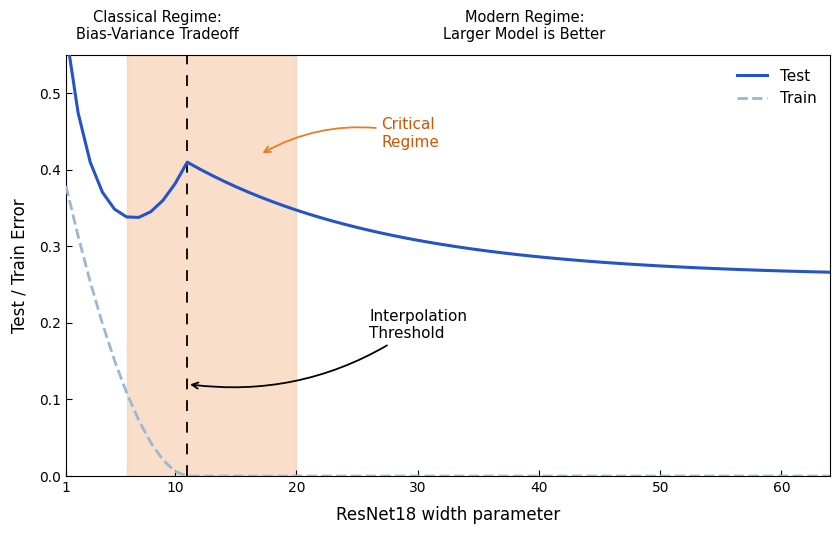

=== 二重降下曲線の重要ポイント ===
古典領域の局所最小点 (Width = 6): テスト誤差 = 0.338, 訓練誤差 = 0.109
補間閾値のピーク (Width = 11): テスト誤差 = 0.410, 訓練誤差 = 0.000 (訓練誤差ゼロ到達)
過剰パラメータ化現代領域 (Width = 64): テスト誤差 = 0.266, 訓練誤差 = 0.000
現代領域 (Width=64) のテスト誤差は古典領域の最小点 (Width=6) よりも 0.072 低い!


In [4]:
# Figure 9.9 の再現: ResNet18 の幅パラメータに対するモデル別二重降下
fig9_9 = generate_figure_9_9()
plt.show()

# DoubleDescentModel クラスによる検証
dd_model = DoubleDescentModel(max_width=64, interp_width=11)
widths, train_err, test_err = dd_model.get_curves()

print("=== 二重降下曲線の重要ポイント ===")
print(f"古典領域の局所最小点 (Width = 6): テスト誤差 = {test_err[5]:.3f}, 訓練誤差 = {train_err[5]:.3f}")
print(f"補間閾値のピーク (Width = 11): テスト誤差 = {test_err[10]:.3f}, 訓練誤差 = {train_err[10]:.3f} (訓練誤差ゼロ到達)")
print(f"過剰パラメータ化現代領域 (Width = 64): テスト誤差 = {test_err[-1]:.3f}, 訓練誤差 = {train_err[-1]:.3f}")
print(f"現代領域 (Width=64) のテスト誤差は古典領域の最小点 (Width=6) よりも {test_err[5] - test_err[-1]:.3f} 低い!")


### 2.3 エポック別二重降下 (Epoch-wise Double Descent)

二重降下現象は、モデルのパラメータ数だけでなく、**学習エポック数 (Training Epochs)** をモデル複雑さの指標とした場合にも観察されます（Figure 9.10）。

- **小型モデル (Small Model, width = 3)**:
  表現能力が低いため補間閾値に達せず、エポック数に対してテスト誤差は単調に減少して収束します。
- **中間モデル (Intermediate Model, width = 12)**:
  エポックの進行に伴い、従来の過適合を示し、途中でテスト誤差が上昇に転じて高いまま推移します。
- **大型モデル (Large Model, width = 64)**:
  初期に急速にテスト誤差が減少した後、エポック中盤の補間閾値付近で一度上昇（ピーク）を示し、さらに学習を進めると**再びテスト誤差が下降して最低誤差を達成**します（エポック別二重降下）。


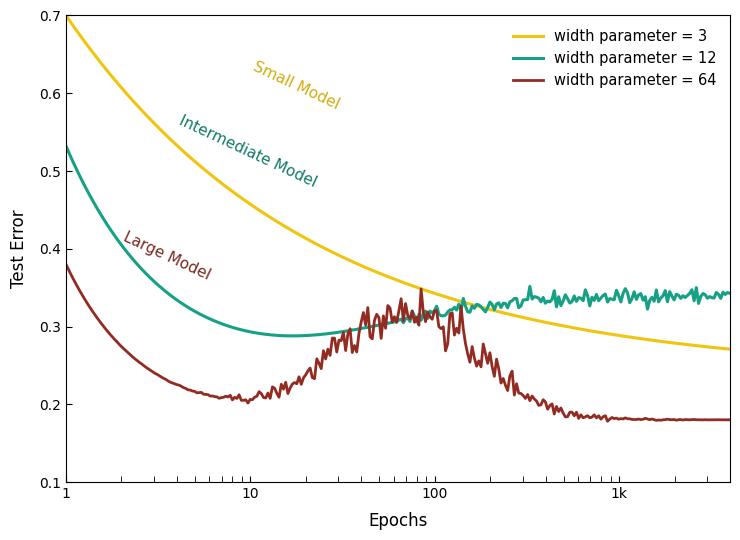

In [5]:
# Figure 9.10 の再現: ResNet18 におけるエポック別二重降下
fig9_10 = generate_figure_9_10()
plt.show()


### 2.4 サンプル別非単調性とデータ増大のパラドックス (Sample-wise Non-monotonicity)

二重降下現象がもたらす最も皮肉で衝撃的な帰結は、**「訓練データ数を増やすと、かえってテスト誤差が悪化する」** という領域が存在する点です（Nakkiran et al., 2019, Figure 9.11）。

通常、「データ数が多いほど汎化性能は向上する」と信じられています。しかし：
- 訓練データセットのサイズを $N_1 = 4,000$ から $N_2 = 18,000$ に増加させると、データを完全に記憶するための必要パラメータ数（補間閾値）が右側にシフトします。
- このとき、$N_1 = 4,000$ ではすでに補間閾値を超えて平滑な現代領域にあったモデルが、$N_2 = 18,000$ のデータ集合に対しては**まさに臨界領域（補間ピークの山）の直撃**を受けてしまいます。
- その結果、特定のモデル複雑さの範囲において、データ数を 4.5倍に増やしたにもかかわらずテスト誤差が悪化する現象が生じます。


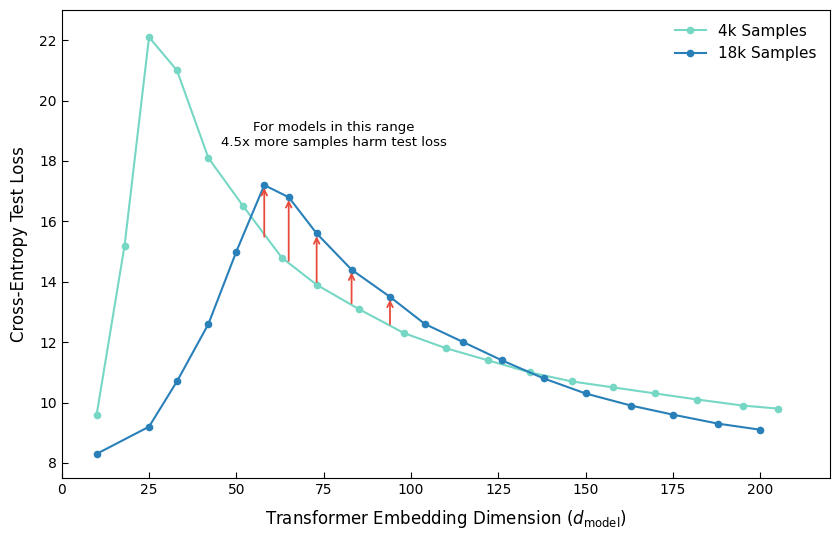

In [6]:
# Figure 9.11 の再現: Transformer 埋め込み次元に対するサンプル別非単調性
fig9_11 = generate_figure_9_11()
plt.show()


---
## 3. まとめと第9.4節への展望

### 本節で学んだ重要概念
1. **学習曲線と早期終了**:
   訓練誤差の単調減少に対し、検証誤差は極小値を持つ。早期終了は検証誤差最小点で学習を停止することで最適なモデル複雑さを実現する。
2. **早期終了と重み減衰の等価性**:
   2次誤差曲面において、勾配流の連続解 $w_i(t) = (1 - e^{-\eta_i t}) w_i^\star$ は、曲率の大きい方向を速やかに学習し、曲率の小さい平坦な方向を抑制する。これは $\tau \eta \sim 1/\lambda$ の関係で重み減衰と数学的に等価である。
3. **二重降下現象 (Double Descent)**:
   モデル複雑さ・学習時間・データサイズの軸において、古典的U字曲線と補間閾値のピークを経て、過剰パラメータ化された現代領域でさらなる汎化誤差の低下が生じる。
4. **過剰パラメータ化の利点**:
   補間閾値を超えた領域では、SGDの暗黙の正則化（最小ノルムバイアス）によって過学習することなく優れた汎化性能が得られる。

### 次節への展開
重み減衰や早期終了はパラメータのノルムや学習時間を制限することで複雑さを抑えますが、ネットワークの構造自体に制約を課す手法として**パラメータ共有 (Parameter Sharing)** があります。
次節 **第9.4節「パラメータ共有 (Parameter Sharing)」** では、畳み込み結合の基礎となるハードな重み共有と、ガウス混合モデル事前分布を用いた**ソフト重み共有 (Soft Weight Sharing)** について探求します。
